In [1]:
%load_ext autoreload

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import pyvista as pv
import vtk
import jax as jx
import jax.numpy as jnp
import os
import jaxpinns.architectures  as jxp_ar
import jaxpinns.optimizers  as jxp_op
import datetime

from jaxpinns.loggers import logger

In [2]:
%autoreload 

from Fibernet2.Generator import Generator

In [3]:
hiperparams = {
    "geometry_file":"./example/LA_model.vtk",
    "create_TA_maps":True, # "fibers" must be on the geometry, if True "maps_files" ignored
    "maps_files":["LA_model_map1.csv", "LA_model_map2.csv", "LA_model_map3.csv"],
    "geometry_file_smooth":None, #"./data/LA_model_smooth_basis.vtk",
    # If "geometry_file_smooth":None , a basis will be generated.
    "area_multiplier":None,#1e-8,#micrometer2 to cm2: 1e-8|milimeter2 to cm2: 1e-2
    # If "area_multiplier":None , will be automatically defined
    # If "create_TA_maps":True , the following parameters are used
    "maps":3,
    "density":16, # ppm/area [points/cm2]
    "noise_ms":0,
    # The Eigfuns are only used for extended and laplace
    # We can import pre-calculated Eigen functions
    "input_precalculated": None,
    # In case we do not import pre-calculated Eigfuns
    "N_eig_max":200,
    "n_eigs":20, 
    "extend_n_layers":3,
    # Arquitecture hyperparameters
    "ensemble_size":10,
    "layers" : [20]*5 + [1],
    "CVlayers" : [20]*7 + [3],
    "lambda_prior":1e-2,
    "scaled":True,
    "CVmax":3.,
    # Training Hyperparameters
    "batch_size":64,
    "lambda_pde":1.e-4,
    "lambda_tve":1.e-7,
    "lambda_tva":1.e-9,
    "lambda_df":1.e0,
    "learning_rate":1e-3,
    # Random seeds
    "init_key":123,#123 #it takes care of weight initialization
    "seed":456, #it takes care of the initial seed of the batches
    "gen_key_1":1651,#789, #it takes care of initialitation of TAs
    "gen_key_2":1011,#1011, #it takes care of the sampling points
}

gen = Generator(hiperparams)
data = pv.UnstructuredGrid(gen.params["geometry_file"])
data.points *= np.sqrt(gen.params["area_multiplier"])

Function createbasis(<Fibernet2.Generator.Generator object at 0x000002CCE5AEF940>,) {} Took 3.6530 seconds
Function createmaps(<Fibernet2.Generator.Generator object at 0x000002CCE5AEF940>,) {} Took 75.7783 seconds


In [4]:
hiperparams["type_model"] = "delta"
dataset = gen.dataset(hiperparams)

Original mesh has 33351 vertices and 66212 faces.
Extending holes on mesh with 3 layers of triangles...
Layer 01/03
Layer 02/03
Layer 03/03
5 holes extended
Extended mesh has 34839 vertices and 69188 faces.
Computing Laplacian
Computing eigen values
Function _init_delta(<Fibernet2.Generator.Generator object at 0x000002CCE5AEF940>,) {} Took 49.4224 seconds


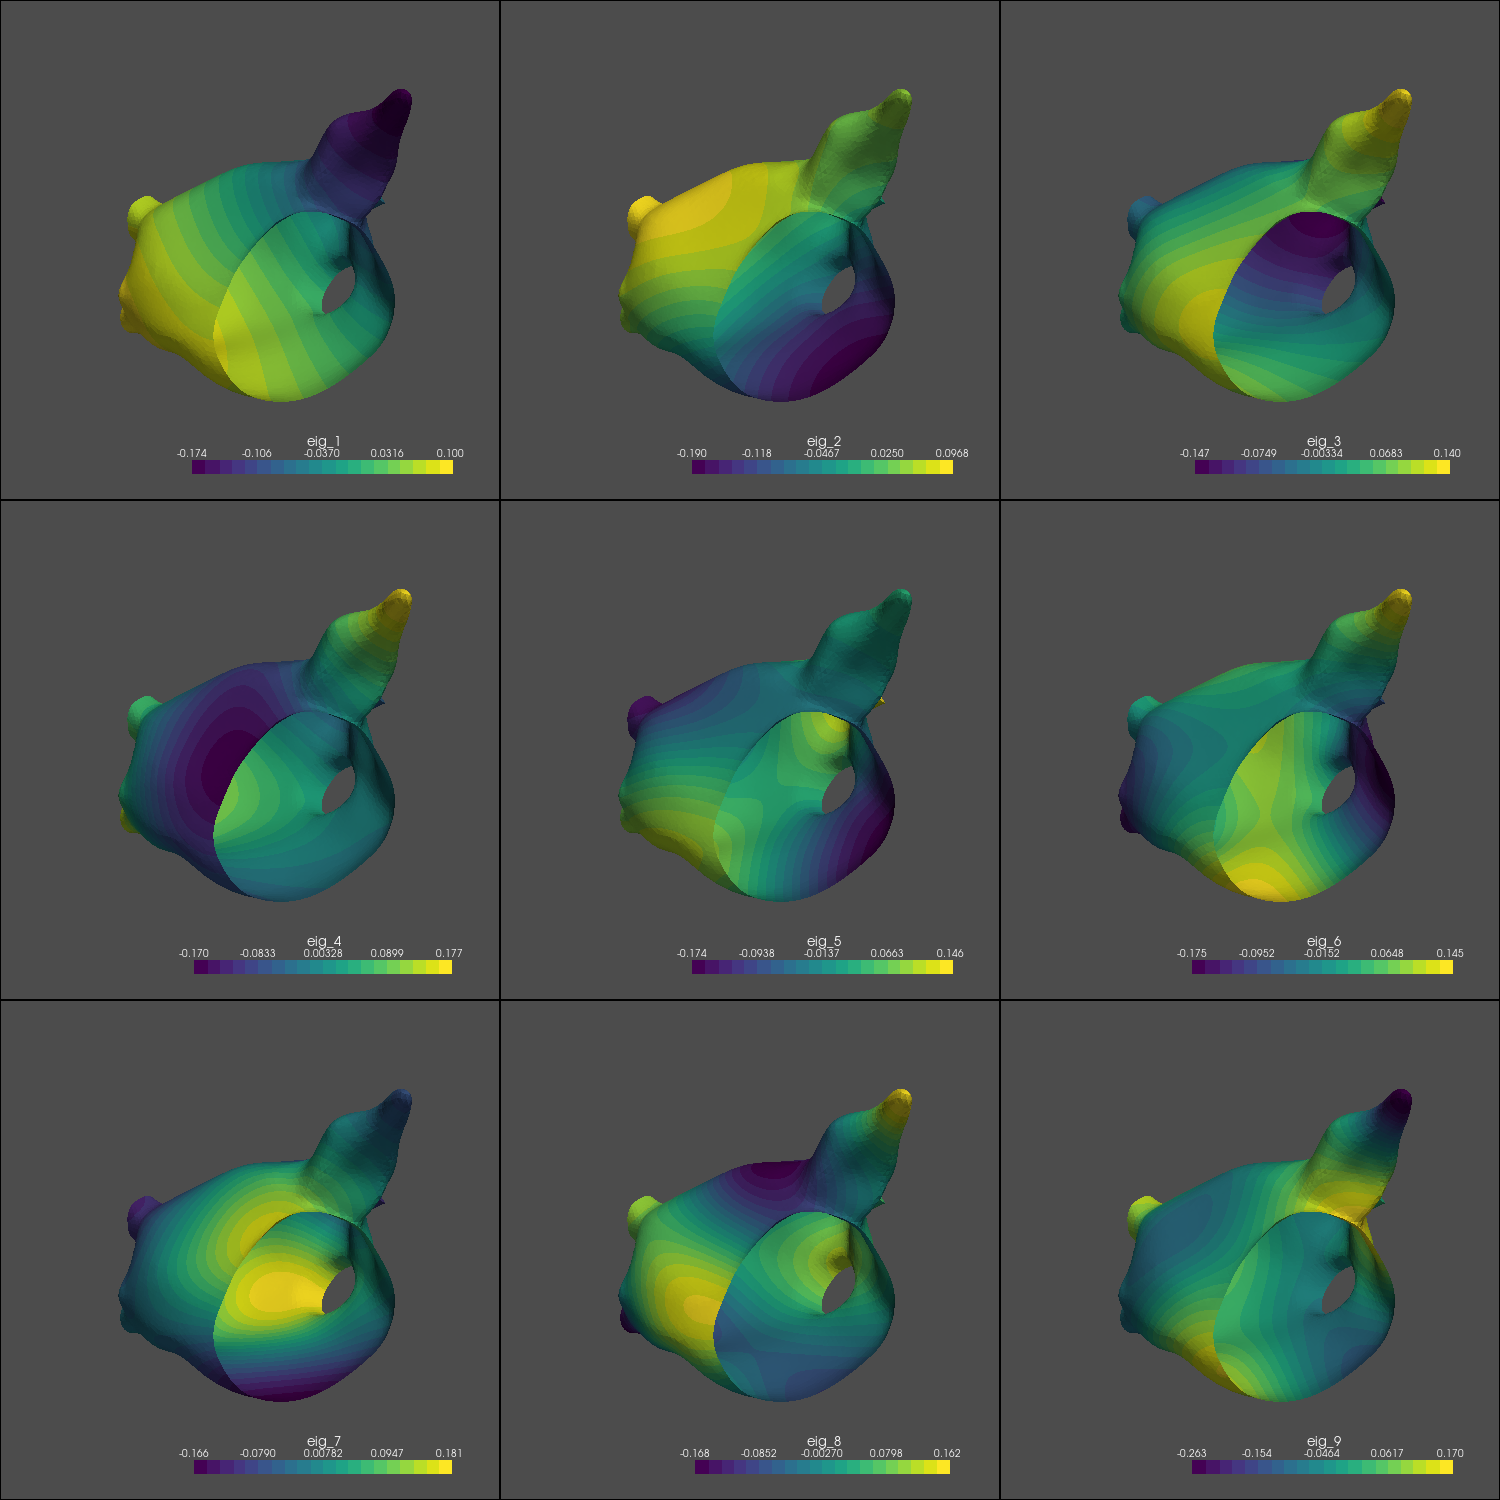

In [5]:
p = pv.Plotter(notebook=True, shape=(3,3),window_size=(1500,1500))
st = 1
for i in range(9):
    data[f"eig_{st+i}"] = gen.F_full[:,st+i]
    cmap = plt.get_cmap("viridis", 20)
    p.subplot(i//3,i%3)

    p.add_mesh(data, scalars=f"eig_{st+i}", cmap=cmap, copy_mesh=True)
    p.camera_position = "xy"
p.show(jupyter_backend='static')

In [6]:
%autoreload 

from Fibernet2.Handler import HandlerRPN

models = {}
handlers = {}
for tmodel in ["delta",  "original"]:
    hiperparams["type_model"] = tmodel
    handlers[tmodel]=HandlerRPN(hiperparams, gen)
    models[tmodel]=handlers[tmodel].model

In [7]:
for k in handlers.keys():
    handlers[k].train(int(1e3))

100%|██████████| 1000/1000 [00:18<00:00, 52.77it/s, loss=0.0009465983, loss_data=0.0009409773, loss_pde=0.05615757, loss_regu=(DeviceArray(0.05155298, dtype=float32), DeviceArray(0.07897774, dtype=float32))] 


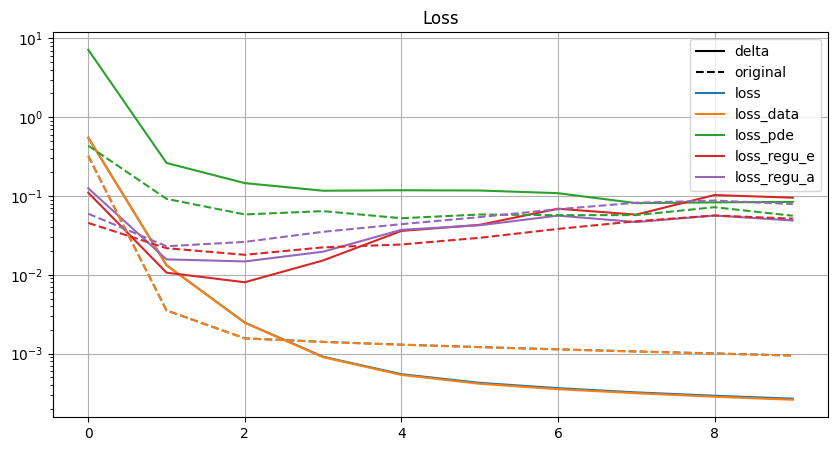

In [8]:
lf = ["-", "--", "."]
plt.figure(figsize=(10,5))
plt.title("Loss")
plt.semilogy()
for i, k in enumerate(models.keys()):
    plt.plot(models[k].training_log['loss'], lf[i])
    plt.plot(models[k].training_log['loss_data'], lf[i])
    plt.plot(models[k].training_log['loss_pde'], lf[i])
    plt.plot(models[k].training_log['loss_regu'], lf[i])
    plt.plot([],[], lf[i], c="k",label=k)
    plt.gca().set_prop_cycle(None)
    
plt.plot([],[],label="loss", ms=1)
plt.plot([],[],label="loss_data", ms=1)
plt.plot([],[],label="loss_pde", ms=1)
plt.plot([],[],label="loss_regu_e", ms=1)
plt.plot([],[],label="loss_regu_a", ms=1)
plt.grid()
plt.legend()
plt.show()

Activation Times Results for model 3 in ensamble


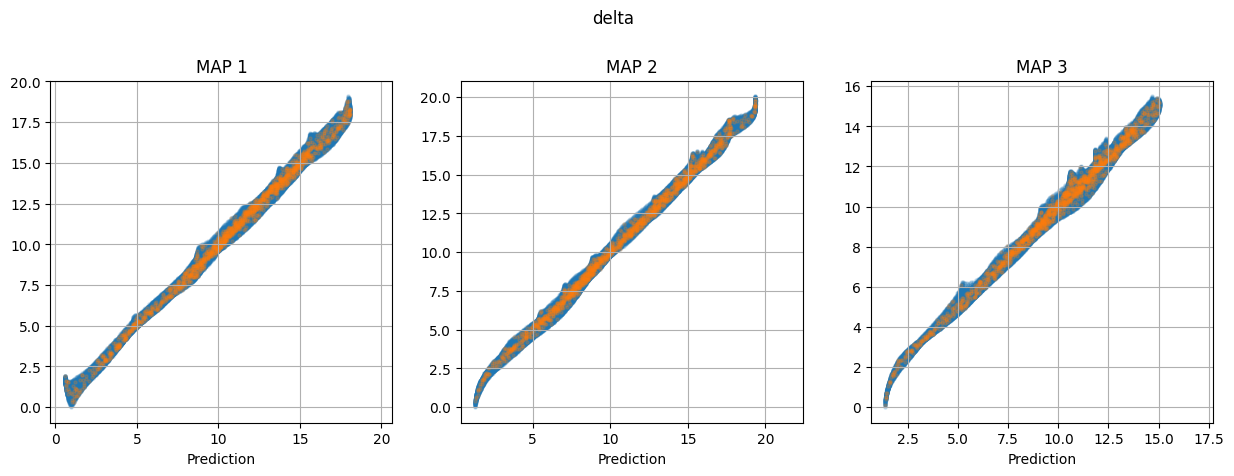

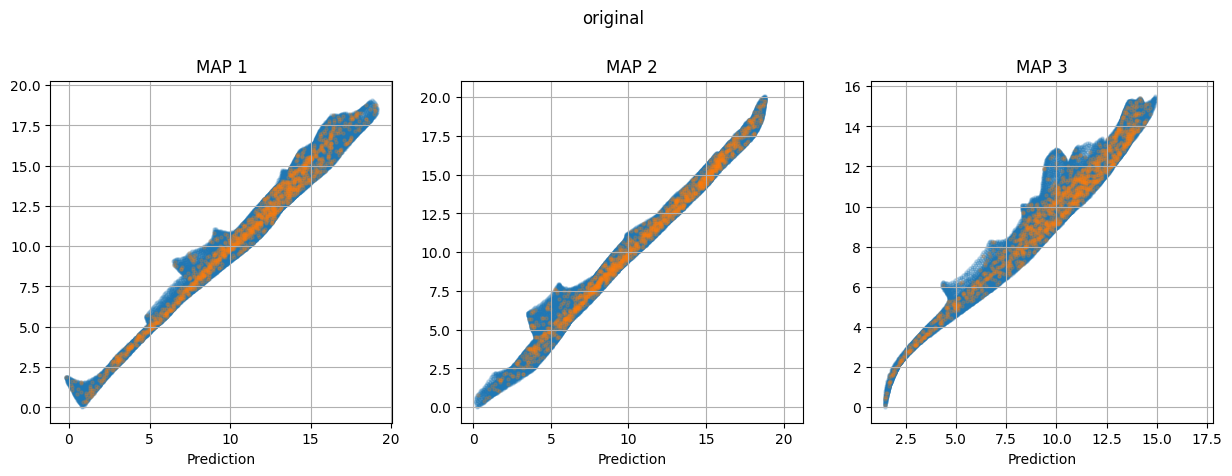

In [9]:
n_model=3
print(f"Activation Times Results for model {n_model} in ensamble")
for j, tm in enumerate(models.keys()):
    sample_pred, pred, sample_true = handlers[tm].predictAT(return_times=True)
    maps_plot = pred.shape[-1]//3+pred.shape[-1]%3
    plt.figure(figsize=(15,5*maps_plot))
    plt.suptitle(tm)
    for i in range(pred.shape[-1]):
        plt.subplot(maps_plot,3,1+i)
        plt.title(f"MAP {i+1}")
        if hiperparams["create_TA_maps"]:
            # if not, the groundtruth does not exist
            plt.scatter(pred[n_model,...,i], gen.phis[:,i], alpha=0.2, s=5)
        plt.scatter(sample_pred[i][n_model], sample_true[i], alpha=0.2, s=5)
        plt.xlabel("Prediction")
        plt.grid()
        plt.axis("square")
    plt.show()

In [18]:
name_file = hiperparams["geometry_file"].split("/")[-1].split(".")[0]
timecode  = datetime.datetime.now().strftime("%m%d%H%M")

data = pv.UnstructuredGrid(gen.params["geometry_file"])
for j, tm in enumerate(models.keys()):
    sample_pred, predicted_times = handlers[tm].predictAT(return_times=False)
    vals, vects = handlers[tm].predictAngles()
    pred_fibers = vects[...,2]
    medoidfibers = handlers[tm].aggragateAngles("Medoid")
    tensorfibers = handlers[tm].aggragateAngles("Mean_Tensor")
    if gen.params["create_TA_maps"]:
        mismatch = []
        for j in range(models[tm].enssiz):
            D_mismatch_rad = np.arccos(np.clip(np.abs(np.sum(gen.D[..., :, 2]*pred_fibers[j],1)),0.,1.))
            fiber_orientation_error = np.rad2deg(np.mean(D_mismatch_rad))
            D_mismatch_degree = np.rad2deg(D_mismatch_rad)
            D_mismatch_degree_dist = np.rad2deg(np.percentile(D_mismatch_rad, [25,50,75]))
            mismatch.append(D_mismatch_degree)
        mismatch = np.array(mismatch)
        D_mismatch_rad = np.arccos(np.clip(np.abs(np.sum(gen.D[..., :, 2]*tensorfibers,1)),0.,1.))
        fiber_orientation_error = np.rad2deg(np.mean(D_mismatch_rad))
        mismatch_t = np.rad2deg(D_mismatch_rad)
        D_mismatch_rad = np.arccos(np.clip(np.abs(np.sum(gen.D[..., :, 2]*medoidfibers,1)),0.,1.))
        fiber_orientation_error = np.rad2deg(np.mean(D_mismatch_rad))
        mismatch_m = np.rad2deg(D_mismatch_rad)
    ######################################
    name_iter = name_file+f'_{timecode}_N{hiperparams["noise_ms"]:2.1f}'
    name_iter+=f'D{hiperparams["density"]:2.1f}M{hiperparams["maps"]}E{hiperparams["ensemble_size"]}'
    name_iter+=f"_{tm}"
    print(name_iter)
    mesh = pv.UnstructuredGrid({vtk.VTK_TRIANGLE: data.cells_dict[vtk.VTK_TRIANGLE]}, data.points)

    n = data.extract_surface().compute_normals()["Normals"]
    if gen.params["create_TA_maps"]:
        mesh["fibers_true"] = data["fibers"]-n * np.sum(data["fibers"] * n, axis=-1, keepdims=True)
        mesh["angle_error"] = mismatch.T
        mesh["angle_error_tensor"] = mismatch_t
        mesh["angle_error_medoid"] = mismatch_m
    mesh["vf_smooth"] = gen.smooth_basis
    if gen.init_datasets["delta"]:
        mesh["eig_func"] = gen.F_full[:,:hiperparams["n_eigs"]]
    for i in range(predicted_times.shape[-1]): 
        if gen.params["create_TA_maps"]:
            mesh[f"phi_{i+1}_true"] = gen.phis[...,i]
        mesh[f"phi_{i+1}_pred"] = predicted_times[...,i].T
    # mesh["e1"] = D_cv[...,0].T
    # mesh["e2"] = D_cv[...,1].T
    # mesh["alpha"] = D_cv[...,2].T
    for i in range(hiperparams["ensemble_size"]):
        mesh[f"fibers_pred_{i+1}"] =  pred_fibers[i]
    mesh["fibers_tensor_pred"] =  tensorfibers
    mesh["fibers_medoid_pred"] = medoidfibers

    mesh.save(name_iter+"_test.vtk")

100%|██████████| 1000/1000 [00:07<00:00, 127.73it/s]


LA_model_09070233_N0.0D16.0M3E10_delta


100%|██████████| 1000/1000 [00:07<00:00, 129.06it/s]


LA_model_09070233_N0.0D16.0M3E10_original
